In [20]:
# Imports and Library Check
import nflreadpy as nfl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [21]:
# Pull NFL Schedule Data (2002-2023)
schedules = nfl.load_schedules().to_pandas()

# Filter to 2002-2023 regular season only
schedules = schedules[(schedules['season'] >= 2002) & (schedules['season'] <= 2023)]
schedules = schedules[schedules['game_type'] == 'REG']

print(f"Shape: {schedules.shape}")
print(f"Seasons covered: {schedules['season'].min()} - {schedules['season'].max()}")
print(f"\nFirst few rows:")
schedules.head()

Shape: (5679, 46)
Seasons covered: 2002 - 2023

First few rows:


,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
777,2002_01_SF_NYG,2002,REG,1,2002-09-05,Thursday,20:30,SF,16.0,NYG,...,7.0,00-0005755,00-0003292,Jeff Garcia,Kerry Collins,Steve Mariucci,Jim Fassel,Gerry Austin,NYC00,Giants Stadium
778,2002_01_NYJ_BUF,2002,REG,1,2002-09-08,Sunday,13:00,NYJ,37.0,BUF,...,6.0,00-0016193,00-0001361,Vinny Testaverde,Drew Bledsoe,Herm Edwards,Gregg Williams,Bob McElwee,BUF00,Ralph Wilson Stadium
779,2002_01_BAL_CAR,2002,REG,1,2002-09-08,Sunday,13:00,BAL,7.0,CAR,...,12.0,00-0019709,00-0012732,Chris Redman,Rodney Peete,Brian Billick,John Fox,Walt Coleman,CAR00,Ericsson Stadium
780,2002_01_MIN_CHI,2002,REG,1,2002-09-08,Sunday,13:00,MIN,23.0,CHI,...,3.0,00-0003739,00-0011276,Daunte Culpepper,Jim Miller,Mike Tice,Dick Jauron,Mike Carey,CHI99,Memorial Stadium (Champaign)
781,2002_01_SD_CIN,2002,REG,1,2002-09-08,Sunday,13:00,SD,34.0,CIN,...,7.0,00-0020531,00-0005589,Drew Brees,Gus Frerotte,Marty Schottenheimer,Dick LeBeau,Johnny Grier,CIN00,Paul Brown Stadium


In [22]:
# Explore Columns and Data Types
print(f"All columns and data types:\n")
print(schedules.dtypes.to_string())

All columns and data types:

game_id              object
season                int32
game_type            object
week                  int32
gameday              object
weekday              object
gametime             object
away_team            object
away_score          float64
home_team            object
home_score          float64
location             object
result              float64
total               float64
overtime            float64
old_game_id          object
gsis                float64
nfl_detail_id        object
pfr                  object
pff                 float64
espn                 object
ftn                 float64
away_rest             int32
home_rest             int32
away_moneyline      float64
home_moneyline      float64
spread_line         float64
away_spread_odds    float64
home_spread_odds    float64
total_line          float64
under_odds          float64
over_odds           float64
div_game              int32
roof                 object
surface            

In [23]:
# Create Target Variable and Select Key Columns
# Create home_win column (1 = home team won, 0 = loss/tie)
schedules['home_win'] = (schedules['result'] > 0).astype(int)

# Select the key columns we care about for this project
key_cols = [
    'season', 'week', 'gameday', 'weekday',
    'home_team', 'away_team',
    'home_score', 'away_score', 'result',
    'home_win',  # our target variable
    'spread_line', 'total_line',  # Vegas features
    'home_rest', 'away_rest',  # rest days
    'roof', 'surface', 'temp', 'wind',  # weather/stadium
    'home_coach', 'away_coach',
    'stadium'
]

df = schedules[key_cols].copy()

print(f"Shape of working dataframe: {df.shape}")
print(f"\nHome team win rate: {df['home_win'].mean():.3f}")
print(f"Total home wins: {df['home_win'].sum()}")
print(f"Total home losses: {(df['home_win'] == 0).sum()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

Shape of working dataframe: (5679, 21)

Home team win rate: 0.562
Total home wins: 3192
Total home losses: 2487

Missing values per column:
season            0
week              0
gameday           0
weekday           0
home_team         0
away_team         0
home_score        0
away_score        0
result            0
home_win          0
spread_line       0
total_line        0
home_rest         0
away_rest         0
roof              0
surface           0
temp           1638
wind           1638
home_coach        0
away_coach        0
stadium           0
dtype: int64


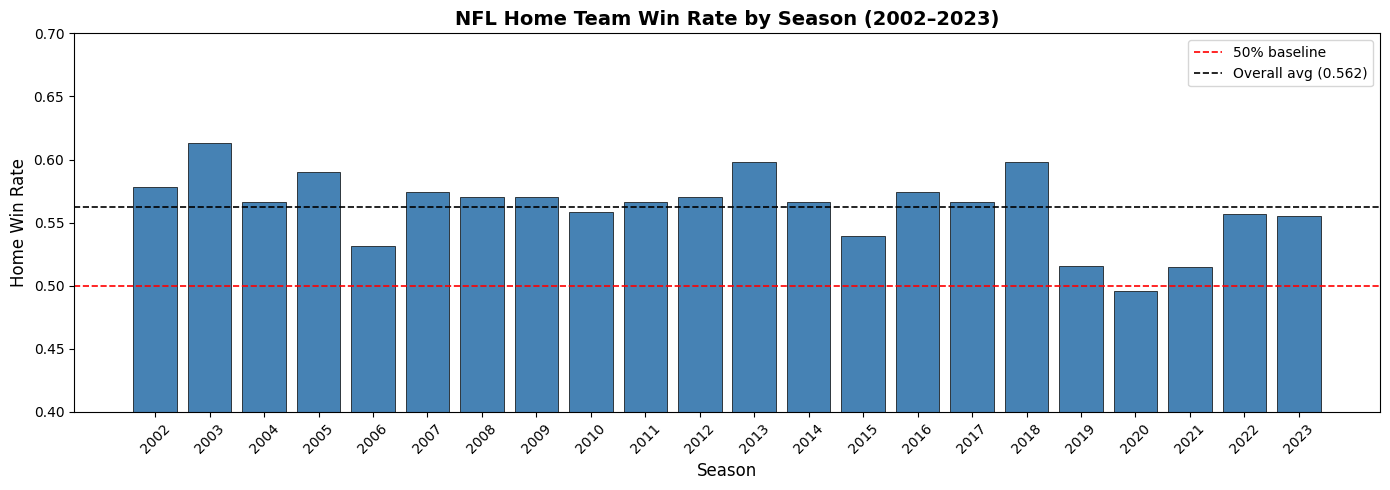

season
2002    0.578
2003    0.613
2004    0.566
2005    0.590
2006    0.531
2007    0.574
2008    0.570
2009    0.570
2010    0.559
2011    0.566
2012    0.570
2013    0.598
2014    0.566
2015    0.539
2016    0.574
2017    0.566
2018    0.598
2019    0.516
2020    0.496
2021    0.515
2022    0.557
2023    0.555


In [24]:
# Home Win Rate by Season
plt.figure(figsize=(14, 5))
win_by_season = df.groupby('season')['home_win'].mean()

plt.bar(win_by_season.index, win_by_season.values, color='steelblue', edgecolor='black', linewidth=0.5)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.2, label='50% baseline')
plt.axhline(y=df['home_win'].mean(), color='black', linestyle='--', linewidth=1.2, label=f'Overall avg ({df["home_win"].mean():.3f})')

plt.title('NFL Home Team Win Rate by Season (2002–2023)', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Home Win Rate', fontsize=12)
plt.ylim(0.4, 0.7)
plt.xticks(win_by_season.index, rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('home_win_rate_by_season.png', dpi=150)
plt.show()

print(win_by_season.round(3).to_string())

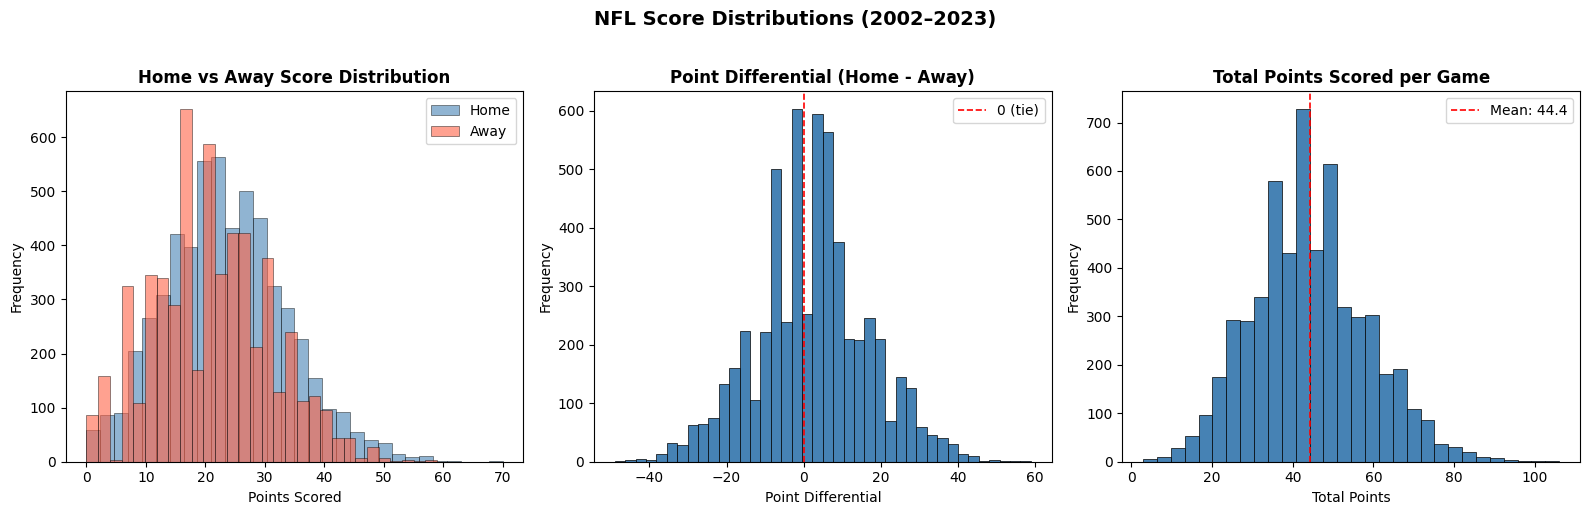

Avg home score: 23.3
Avg away score: 21.1
Avg total points scored: 44.4
Avg point differential: 2.2


In [25]:
# Score Distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Home vs Away score distribution
axes[0].hist(df['home_score'], bins=30, alpha=0.6, color='steelblue', label='Home', edgecolor='black', linewidth=0.5)
axes[0].hist(df['away_score'], bins=30, alpha=0.6, color='tomato', label='Away', edgecolor='black', linewidth=0.5)
axes[0].set_title('Home vs Away Score Distribution', fontweight='bold')
axes[0].set_xlabel('Points Scored')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Point differential (result column)
axes[1].hist(df['result'], bins=40, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.2, label='0 (tie)')
axes[1].set_title('Point Differential (Home - Away)', fontweight='bold')
axes[1].set_xlabel('Point Differential')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Total points scored (home + away)
df['total_scored'] = df['home_score'] + df['away_score']
axes[2].hist(df['total_scored'], bins=30, color='steelblue', edgecolor='black', linewidth=0.5)
axes[2].axvline(x=df['total_scored'].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {df["total_scored"].mean():.1f}')
axes[2].set_title('Total Points Scored per Game', fontweight='bold')
axes[2].set_xlabel('Total Points')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('NFL Score Distributions (2002–2023)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('score_distributions.png', dpi=150)
plt.show()

print(f"Avg home score: {df['home_score'].mean():.1f}")
print(f"Avg away score: {df['away_score'].mean():.1f}")
print(f"Avg total points scored: {df['total_scored'].mean():.1f}")
print(f"Avg point differential: {df['result'].mean():.1f}")

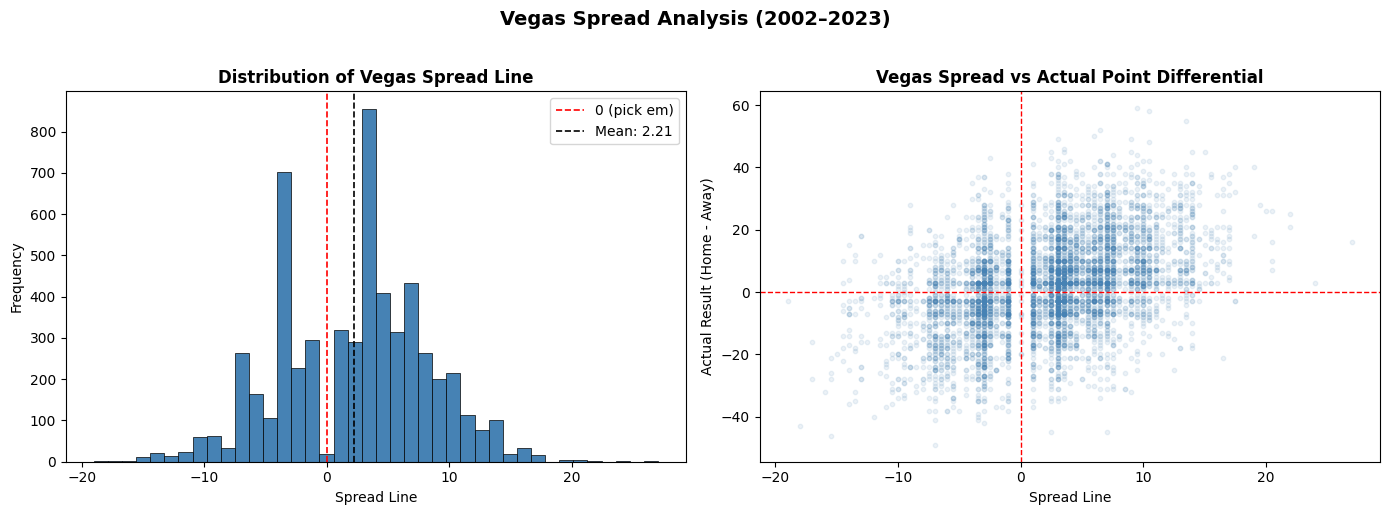

Correlation between spread_line and result: 0.427
(Positive = higher spread means home team wins by more)

Spread line stats:
count    5679.00
mean        2.21
std         6.00
min       -19.00
25%        -3.00
50%         3.00
75%         6.50
max        27.00
Name: spread_line, dtype: float64


In [26]:
# Vegas Spread Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of Vegas spread line
axes[0].hist(df['spread_line'], bins=40, color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.2, label='0 (pick em)')
axes[0].axvline(x=df['spread_line'].mean(), color='black', linestyle='--', linewidth=1.2,
                label=f'Mean: {df["spread_line"].mean():.2f}')
axes[0].set_title('Distribution of Vegas Spread Line', fontweight='bold')
axes[0].set_xlabel('Spread Line')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Spread line vs actual result
axes[1].scatter(df['spread_line'], df['result'], alpha=0.1, color='steelblue', s=10)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.0)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.0)
axes[1].set_title('Vegas Spread vs Actual Point Differential', fontweight='bold')
axes[1].set_xlabel('Spread Line')
axes[1].set_ylabel('Actual Result (Home - Away)')

plt.suptitle('Vegas Spread Analysis (2002–2023)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('vegas_spread_analysis.png', dpi=150)
plt.show()

# Check spread convention by looking at correlation with result
corr = df['spread_line'].corr(df['result'])
print(f"Correlation between spread_line and result: {corr:.3f}")
print(f"(Positive = higher spread means home team wins by more)")
print(f"\nSpread line stats:")
print(df['spread_line'].describe().round(2))

Games where home team was favored: 3671
Games where home team was underdog: 2008
Pick em games (spread = 0): 18

Win rate when home team is favored: 0.676
Win rate when home team is underdog: 0.355

Vegas spread picks correct direction: 0.663
(Benchmark accuracy our models will be compared against)


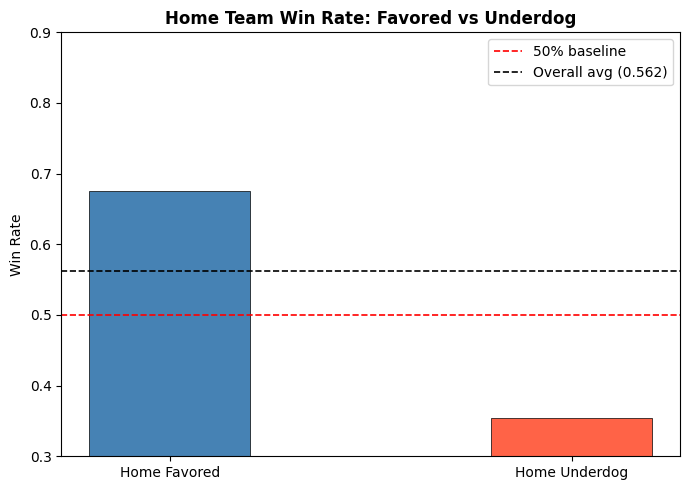

In [27]:
# Favored Team Win Rates
# Positive spread = home team favored, negative = away team favored
df['home_favored'] = (df['spread_line'] > 0).astype(int)

favored_win_rate = df[df['home_favored'] == 1]['home_win'].mean()
underdog_win_rate = df[df['home_favored'] == 0]['home_win'].mean()
pickem_games = (df['spread_line'] == 0).sum()

print(f"Games where home team was favored: {df['home_favored'].sum()}")
print(f"Games where home team was underdog: {(df['home_favored'] == 0).sum()}")
print(f"Pick em games (spread = 0): {pickem_games}")
print(f"\nWin rate when home team is favored: {favored_win_rate:.3f}")
print(f"Win rate when home team is underdog: {underdog_win_rate:.3f}")

# Vegas spread direction accuracy
df['spread_correct'] = (
    ((df['spread_line'] > 0) & (df['home_win'] == 1)) |
    ((df['spread_line'] < 0) & (df['home_win'] == 0))
).astype(int)

print(f"\nVegas spread picks correct direction: {df['spread_correct'].mean():.3f}")
print(f"(Benchmark accuracy our models will be compared against)")

# Plot win rates
categories = ['Home Favored', 'Home Underdog']
win_rates = [favored_win_rate, underdog_win_rate]

plt.figure(figsize=(7, 5))
bars = plt.bar(categories, win_rates, color=['steelblue', 'tomato'], 
               edgecolor='black', linewidth=0.5, width=0.4)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.2, label='50% baseline')
plt.axhline(y=df['home_win'].mean(), color='black', linestyle='--', 
            linewidth=1.2, label=f'Overall avg ({df["home_win"].mean():.3f})')
plt.title('Home Team Win Rate: Favored vs Underdog', fontweight='bold')
plt.ylabel('Win Rate')
plt.ylim(0.3, 0.9)
plt.legend()
plt.tight_layout()
plt.savefig('favored_vs_underdog.png', dpi=150)
plt.show()

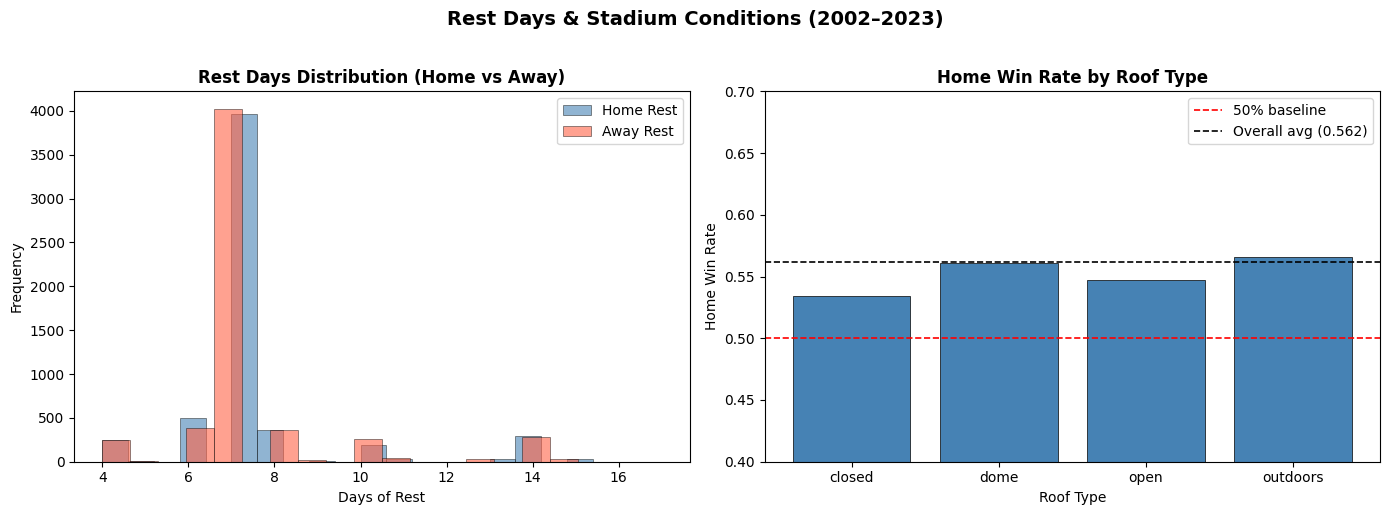

Home win rate by roof type:
           mean  count
roof                  
closed    0.534    504
dome      0.561    892
open      0.547    128
outdoors  0.566   4155

Avg home rest days: 7.4
Avg away rest days: 7.5

Avg home rest advantage: -0.06 days
Correlation of rest advantage with home win: 0.026


In [28]:
# Rest Days and Roof/Weather Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rest days distribution
axes[0].hist(df['home_rest'], bins=20, alpha=0.6, color='steelblue', 
             label='Home Rest', edgecolor='black', linewidth=0.5)
axes[0].hist(df['away_rest'], bins=20, alpha=0.6, color='tomato', 
             label='Away Rest', edgecolor='black', linewidth=0.5)
axes[0].set_title('Rest Days Distribution (Home vs Away)', fontweight='bold')
axes[0].set_xlabel('Days of Rest')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Win rate by roof type
roof_wins = df.groupby('roof')['home_win'].agg(['mean', 'count']).round(3)
axes[1].bar(roof_wins.index, roof_wins['mean'], color='steelblue', 
            edgecolor='black', linewidth=0.5)
axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=1.2, label='50% baseline')
axes[1].axhline(y=df['home_win'].mean(), color='black', linestyle='--',
                linewidth=1.2, label=f'Overall avg ({df["home_win"].mean():.3f})')
axes[1].set_title('Home Win Rate by Roof Type', fontweight='bold')
axes[1].set_xlabel('Roof Type')
axes[1].set_ylabel('Home Win Rate')
axes[1].set_ylim(0.4, 0.7)
axes[1].legend()

plt.suptitle('Rest Days & Stadium Conditions (2002–2023)', fontsize=14, 
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rest_roof_analysis.png', dpi=150)
plt.show()

print("Home win rate by roof type:")
print(roof_wins.to_string())
print(f"\nAvg home rest days: {df['home_rest'].mean():.1f}")
print(f"Avg away rest days: {df['away_rest'].mean():.1f}")

# Rest advantage
df['rest_advantage'] = df['home_rest'] - df['away_rest']
print(f"\nAvg home rest advantage: {df['rest_advantage'].mean():.2f} days")
rest_corr = df['rest_advantage'].corr(df['home_win'])
print(f"Correlation of rest advantage with home win: {rest_corr:.3f}")

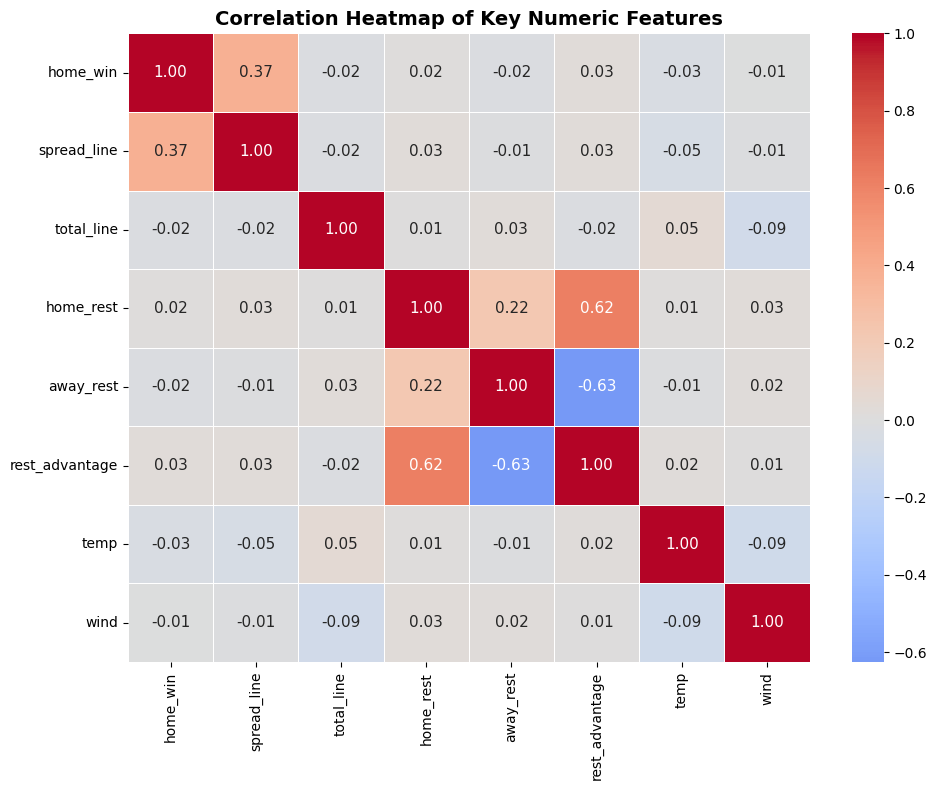

Correlations with home_win:
home_win          1.000
spread_line       0.374
rest_advantage    0.026
home_rest         0.016
wind             -0.009
away_rest        -0.017
total_line       -0.021
temp             -0.033


In [29]:
# Correlation Heatmap
# Select numeric features to correlate against home_win
corr_cols = [
    'home_win', 'spread_line', 'total_line',
    'home_rest', 'away_rest', 'rest_advantage',
    'temp', 'wind'
]

corr_df = df[corr_cols].copy()
corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 11}
)
plt.title('Correlation Heatmap of Key Numeric Features', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("Correlations with home_win:")
print(corr_matrix['home_win'].sort_values(ascending=False).round(3).to_string())

In [30]:
# Variable Summary Table
variable_summary = pd.DataFrame({
    'Variable': [
        'season', 'week', 'home_team', 'away_team',
        'home_score', 'away_score', 'result',
        'home_win', 'spread_line', 'total_line',
        'home_rest', 'away_rest', 'rest_advantage',
        'roof', 'surface', 'temp', 'wind', 'stadium'
    ],
    'Type': [
        'Integer', 'Integer', 'Categorical', 'Categorical',
        'Integer', 'Integer', 'Integer',
        'Binary', 'Float', 'Float',
        'Integer', 'Integer', 'Integer',
        'Categorical', 'Categorical', 'Float', 'Float', 'Categorical'
    ],
    'Role': [
        'Identifier', 'Identifier', 'Identifier', 'Identifier',
        'Outcome', 'Outcome', 'Outcome',
        'Target Variable', 'Feature (Vegas)', 'Feature (Vegas)',
        'Feature', 'Feature', 'Feature (engineered)',
        'Feature', 'Feature', 'Feature', 'Feature', 'Identifier'
    ],
    'Description': [
        'NFL season year (2002-2023)',
        'Week number within the season',
        'Home team abbreviation',
        'Away team abbreviation',
        'Points scored by home team',
        'Points scored by away team',
        'Point differential (home - away)',
        '1 if home team won, 0 if lost/tied',
        'Vegas opening spread (positive = home favored)',
        'Vegas over/under total points line',
        'Days of rest for home team',
        'Days of rest for away team',
        'Home rest minus away rest (engineered)',
        'Stadium roof type (dome/outdoors/closed/open)',
        'Playing surface type',
        'Temperature in fahrenheit (outdoor games only)',
        'Wind speed in mph (outdoor games only)',
        'Stadium name'
    ],
    'Missing': [
        '0', '0', '0', '0',
        '0', '0', '0',
        '0', '0', '0',
        '0', '0', '0',
        '0', '0', '1638', '1638', '0'
    ]
})

print(variable_summary.to_string(index=False))
print(f"\nTotal rows: 5,679")
print(f"Total columns in working dataframe: 21")
print(f"Seasons: 2002-2023 (22 seasons, regular season only)")
print(f"Train set: 2002-2019 | Test set: 2020-2023")

      Variable        Type                 Role                                    Description Missing
        season     Integer           Identifier                    NFL season year (2002-2023)       0
          week     Integer           Identifier                  Week number within the season       0
     home_team Categorical           Identifier                         Home team abbreviation       0
     away_team Categorical           Identifier                         Away team abbreviation       0
    home_score     Integer              Outcome                     Points scored by home team       0
    away_score     Integer              Outcome                     Points scored by away team       0
        result     Integer              Outcome               Point differential (home - away)       0
      home_win      Binary      Target Variable             1 if home team won, 0 if lost/tied       0
   spread_line       Float      Feature (Vegas) Vegas opening spread (pos

In [31]:
# Feature Engineering 

# Rolling features using only past data to avoid leakage.
# All features are computed from the schedule dataframe sorted by season/week.

# Sort to ensure chronological order
df = df.sort_values(['season', 'week']).reset_index(drop=True)

# 1. Rolling win % (last 4 games) for home and away team
def rolling_win_pct(df, team_col, result_col, window=4):
    """Compute rolling win % for each team based on past games only."""
    records = []
    team_history = {}

    for _, row in df.iterrows():
        team = row[team_col]
        if team not in team_history:
            team_history[team] = []

        history = team_history[team]
        if len(history) >= window:
            pct = sum(history[-window:]) / window
        elif len(history) > 0:
            pct = sum(history) / len(history)
        else:
            pct = 0.5  # neutral prior for first game

        records.append(pct)
        team_history[team].append(row[result_col])

    return records

df['home_rolling_win_pct'] = rolling_win_pct(df, 'home_team', 'home_win')
df['away_rolling_win_pct'] = rolling_win_pct(df, 'away_team', 'home_win')

# 2. Rolling point differential (last 4 games) 
def rolling_point_diff(df, team_col, diff_col, window=4):
    """Rolling avg point differential from each team's perspective."""
    records = []
    team_history = {}

    for _, row in df.iterrows():
        team = row[team_col]
        sign = 1 if team_col == 'home_team' else -1

        if team not in team_history:
            team_history[team] = []

        history = team_history[team]
        if len(history) >= window:
            avg = sum(history[-window:]) / window
        elif len(history) > 0:
            avg = sum(history) / len(history)
        else:
            avg = 0.0

        records.append(avg)
        team_history[team].append(sign * row[diff_col])

    return records

df['home_rolling_point_diff'] = rolling_point_diff(df, 'home_team', 'result')
df['away_rolling_point_diff'] = rolling_point_diff(df, 'away_team', 'result')

# 3. Win % advantage (home minus away rolling win %)
df['win_pct_advantage'] = df['home_rolling_win_pct'] - df['away_rolling_win_pct']

# 4. Indoor game flag (1 = dome or closed roof)
df['is_indoor'] = df['roof'].isin(['dome', 'closed']).astype(int)

# 5. Fill missing temp/wind with neutral values for indoor games
df['temp'] = df['temp'].fillna(70)   # neutral indoor temp
df['wind'] = df['wind'].fillna(0)    # no wind indoors

# 6. Season segment (early = weeks 1-6, mid = 7-13, late = 14+)
df['season_segment'] = pd.cut(
    df['week'],
    bins=[0, 6, 13, 99],
    labels=['early', 'mid', 'late']
)

# Preview engineered features
engineered_cols = [
    'home_rolling_win_pct', 'away_rolling_win_pct',
    'home_rolling_point_diff', 'away_rolling_point_diff',
    'win_pct_advantage', 'is_indoor', 'temp', 'wind', 'season_segment'
]

print("=== Engineered Features Preview ===")
print(df[engineered_cols].head(10).to_string(index=False))
print(f"\nShape after feature engineering: {df.shape}")
print(f"Nulls remaining:\n{df[engineered_cols].isnull().sum()}")

=== Engineered Features Preview ===
 home_rolling_win_pct  away_rolling_win_pct  home_rolling_point_diff  away_rolling_point_diff  win_pct_advantage  is_indoor  temp  wind season_segment
                  0.5                   0.5                      0.0                      0.0                0.0          0  73.0   7.0          early
                  0.5                   0.5                      0.0                      0.0                0.0          0  86.0   6.0          early
                  0.5                   0.5                      0.0                      0.0                0.0          0  78.0  12.0          early
                  0.5                   0.5                      0.0                      0.0                0.0          0  85.0   3.0          early
                  0.5                   0.5                      0.0                      0.0                0.0          0  90.0   7.0          early
                  0.5                   0.5               

In [32]:
# Train/Test Split & Preprocessing

import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# Define feature sets
# Excluding Vegas features first, I will add them in a second model version
FEATURES_NO_VEGAS = [
    'week',
    'home_rolling_win_pct',
    'away_rolling_win_pct',
    'home_rolling_point_diff',
    'away_rolling_point_diff',
    'win_pct_advantage',
    'rest_advantage',
    'is_indoor',
    'temp',
    'wind'
]

FEATURES_WITH_VEGAS = FEATURES_NO_VEGAS + ['spread_line', 'total_line']

TARGET = 'home_win'

# Train/Test split by season (no random shuffle, preserves time order)
train = df[df['season'] <= 2019].copy()
test  = df[df['season'] >= 2020].copy()

X_train_nv = train[FEATURES_NO_VEGAS]
X_test_nv  = test[FEATURES_NO_VEGAS]

X_train_v  = train[FEATURES_WITH_VEGAS]
X_test_v   = test[FEATURES_WITH_VEGAS]

y_train = train[TARGET]
y_test  = test[TARGET]

# Scale features
scaler_nv = StandardScaler()
X_train_nv_scaled = scaler_nv.fit_transform(X_train_nv)
X_test_nv_scaled  = scaler_nv.transform(X_test_nv)

scaler_v = StandardScaler()
X_train_v_scaled  = scaler_v.fit_transform(X_train_v)
X_test_v_scaled   = scaler_v.transform(X_test_v)

# Summary
print("=== Train/Test Split Summary ===")
print(f"Training rows : {len(train):,}  (seasons 2002–2019)")
print(f"Test rows     : {len(test):,}   (seasons 2020–2023)")
print(f"\nFeatures (no Vegas) : {len(FEATURES_NO_VEGAS)}")
print(f"Features (w/ Vegas) : {len(FEATURES_WITH_VEGAS)}")
print(f"\nTarget distribution (train):")
print(train[TARGET].value_counts(normalize=True).round(3))
print(f"\nTarget distribution (test):")
print(test[TARGET].value_counts(normalize=True).round(3))

=== Train/Test Split Summary ===
Training rows : 4,608  (seasons 2002–2019)
Test rows     : 1,071   (seasons 2020–2023)

Features (no Vegas) : 10
Features (w/ Vegas) : 12

Target distribution (train):
1    0.569
0    0.431
Name: home_win, dtype: float64

Target distribution (test):
1    0.531
0    0.469
Name: home_win, dtype: float64


In [33]:
# Logistic Regression (Baseline Model)

from sklearn.linear_model import LogisticRegression

# Train without Vegas features
lr_nv = LogisticRegression(max_iter=1000, random_state=42)
lr_nv.fit(X_train_nv_scaled, y_train)

y_pred_nv = lr_nv.predict(X_test_nv_scaled)
y_prob_nv = lr_nv.predict_proba(X_test_nv_scaled)[:, 1]

acc_nv   = accuracy_score(y_test, y_pred_nv)
auc_nv   = roc_auc_score(y_test, y_prob_nv)
loss_nv  = log_loss(y_test, y_prob_nv)

# Train with Vegas features
lr_v = LogisticRegression(max_iter=1000, random_state=42)
lr_v.fit(X_train_v_scaled, y_train)

y_pred_v = lr_v.predict(X_test_v_scaled)
y_prob_v = lr_v.predict_proba(X_test_v_scaled)[:, 1]

acc_v   = accuracy_score(y_test, y_pred_v)
auc_v   = roc_auc_score(y_test, y_prob_v)
loss_v  = log_loss(y_test, y_prob_v)

# Display results
print("=== Logistic Regression Results ===")
print(f"{'Metric':<20} {'No Vegas':>12} {'With Vegas':>12}")
print(f"{'Accuracy':<20} {acc_nv:>12.4f} {acc_v:>12.4f}")
print(f"{'AUC-ROC':<20} {auc_nv:>12.4f} {auc_v:>12.4f}")
print(f"{'Log Loss':<20} {loss_nv:>12.4f} {loss_v:>12.4f}")

# Top feature coefficients (no Vegas version)
import pandas as pd
coef_df = pd.DataFrame({
    'Feature': FEATURES_NO_VEGAS,
    'Coefficient': lr_nv.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("\nTop Feature Coefficients (No Vegas model):")
print(coef_df.to_string(index=False))

=== Logistic Regression Results ===
Metric                   No Vegas   With Vegas
Accuracy                   0.5920       0.6583
AUC-ROC                    0.6250       0.7203
Log Loss                   0.6687       0.6128

Top Feature Coefficients (No Vegas model):
                Feature  Coefficient
home_rolling_point_diff     0.392651
   away_rolling_win_pct     0.080590
         rest_advantage     0.065791
   home_rolling_win_pct     0.031044
              is_indoor     0.006939
                   wind    -0.031602
      win_pct_advantage    -0.034126
                   week    -0.042769
                   temp    -0.072118
away_rolling_point_diff    -0.273356


In [34]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Tune without Vegas features
rf_search_nv = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
rf_search_nv.fit(X_train_nv_scaled, y_train)
best_rf_nv = rf_search_nv.best_estimator_

# Tune with Vegas features
rf_search_v = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
rf_search_v.fit(X_train_v_scaled, y_train)
best_rf_v = rf_search_v.best_estimator_

# Evaluate both
y_pred_rf_nv  = best_rf_nv.predict(X_test_nv_scaled)
y_prob_rf_nv  = best_rf_nv.predict_proba(X_test_nv_scaled)[:, 1]
acc_rf_nv     = accuracy_score(y_test, y_pred_rf_nv)
auc_rf_nv     = roc_auc_score(y_test, y_prob_rf_nv)
loss_rf_nv    = log_loss(y_test, y_prob_rf_nv)

y_pred_rf_v   = best_rf_v.predict(X_test_v_scaled)
y_prob_rf_v   = best_rf_v.predict_proba(X_test_v_scaled)[:, 1]
acc_rf_v      = accuracy_score(y_test, y_pred_rf_v)
auc_rf_v      = roc_auc_score(y_test, y_prob_rf_v)
loss_rf_v     = log_loss(y_test, y_prob_rf_v)

# Display results
print("=== Random Forest Results ===")
print(f"{'Metric':<20} {'No Vegas':>12} {'With Vegas':>12}")
print(f"{'Accuracy':<20} {acc_rf_nv:>12.4f} {acc_rf_v:>12.4f}")
print(f"{'AUC-ROC':<20} {auc_rf_nv:>12.4f} {auc_rf_v:>12.4f}")
print(f"{'Log Loss':<20} {loss_rf_nv:>12.4f} {loss_rf_v:>12.4f}")

print(f"\nBest Params (No Vegas): {rf_search_nv.best_params_}")
print(f"Best Params (With Vegas): {rf_search_v.best_params_}")

# Feature importance (no Vegas version)
importance_df = pd.DataFrame({
    'Feature': FEATURES_NO_VEGAS,
    'Importance': best_rf_nv.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importances (No Vegas model):")
print(importance_df.to_string(index=False))

=== Random Forest Results ===
Metric                   No Vegas   With Vegas
Accuracy                   0.5929       0.6517
AUC-ROC                    0.6118       0.7031
Log Loss                   0.6736       0.6292

Best Params (No Vegas): {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}
Best Params (With Vegas): {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5}

Feature Importances (No Vegas model):
                Feature  Importance
home_rolling_point_diff    0.294362
away_rolling_point_diff    0.248167
   home_rolling_win_pct    0.104406
   away_rolling_win_pct    0.097085
                   temp    0.071482
      win_pct_advantage    0.062208
                   week    0.044626
                   wind    0.044226
         rest_advantage    0.029612
              is_indoor    0.003828


In [35]:
# XGBoost

from xgboost import XGBClassifier

# Define parameter grid for tuning
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Tune without Vegas features
xgb_search_nv = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
xgb_search_nv.fit(X_train_nv_scaled, y_train)
best_xgb_nv = xgb_search_nv.best_estimator_

# Tune with Vegas features
xgb_search_v = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
xgb_search_v.fit(X_train_v_scaled, y_train)
best_xgb_v = xgb_search_v.best_estimator_

# Evaluate both
y_pred_xgb_nv  = best_xgb_nv.predict(X_test_nv_scaled)
y_prob_xgb_nv  = best_xgb_nv.predict_proba(X_test_nv_scaled)[:, 1]
acc_xgb_nv     = accuracy_score(y_test, y_pred_xgb_nv)
auc_xgb_nv     = roc_auc_score(y_test, y_prob_xgb_nv)
loss_xgb_nv    = log_loss(y_test, y_prob_xgb_nv)

y_pred_xgb_v   = best_xgb_v.predict(X_test_v_scaled)
y_prob_xgb_v   = best_xgb_v.predict_proba(X_test_v_scaled)[:, 1]
acc_xgb_v      = accuracy_score(y_test, y_pred_xgb_v)
auc_xgb_v      = roc_auc_score(y_test, y_prob_xgb_v)
loss_xgb_v     = log_loss(y_test, y_prob_xgb_v)

# Display results
print("=== XGBoost Results ===")
print(f"{'Metric':<20} {'No Vegas':>12} {'With Vegas':>12}")
print(f"{'Accuracy':<20} {acc_xgb_nv:>12.4f} {acc_xgb_v:>12.4f}")
print(f"{'AUC-ROC':<20} {auc_xgb_nv:>12.4f} {auc_xgb_v:>12.4f}")
print(f"{'Log Loss':<20} {loss_xgb_nv:>12.4f} {loss_xgb_v:>12.4f}")

print(f"\nBest Params (No Vegas): {xgb_search_nv.best_params_}")
print(f"Best Params (With Vegas): {xgb_search_v.best_params_}")

# Feature importance (no Vegas version)
xgb_importance_df = pd.DataFrame({
    'Feature': FEATURES_NO_VEGAS,
    'Importance': best_xgb_nv.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importances (No Vegas model):")
print(xgb_importance_df.to_string(index=False))

=== XGBoost Results ===
Metric                   No Vegas   With Vegas
Accuracy                   0.5910       0.6517
AUC-ROC                    0.6135       0.7156
Log Loss                   0.6750       0.6202

Best Params (No Vegas): {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best Params (With Vegas): {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

Feature Importances (No Vegas model):
                Feature  Importance
   away_rolling_win_pct    0.171111
home_rolling_point_diff    0.164599
   home_rolling_win_pct    0.154208
away_rolling_point_diff    0.141289
                   week    0.078012
                   temp    0.073831
      win_pct_advantage    0.068262
         rest_advantage    0.061586
                   wind    0.056882
              is_indoor    0.030222


In [36]:
# Neural Network

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)

def build_model(input_dim, learning_rate=0.001, dropout_rate=0.3, units=64):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(units, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(units // 2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

# Train without Vegas features
nn_nv = build_model(input_dim=X_train_nv_scaled.shape[1])
nn_nv.fit(
    X_train_nv_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

y_prob_nn_nv = nn_nv.predict(X_test_nv_scaled, verbose=0).flatten()
y_pred_nn_nv = (y_prob_nn_nv >= 0.5).astype(int)
acc_nn_nv    = accuracy_score(y_test, y_pred_nn_nv)
auc_nn_nv    = roc_auc_score(y_test, y_prob_nn_nv)
loss_nn_nv   = log_loss(y_test, y_prob_nn_nv)

# Train with Vegas features
nn_v = build_model(input_dim=X_train_v_scaled.shape[1])
nn_v.fit(
    X_train_v_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

y_prob_nn_v = nn_v.predict(X_test_v_scaled, verbose=0).flatten()
y_pred_nn_v = (y_prob_nn_v >= 0.5).astype(int)
acc_nn_v    = accuracy_score(y_test, y_pred_nn_v)
auc_nn_v    = roc_auc_score(y_test, y_prob_nn_v)
loss_nn_v   = log_loss(y_test, y_prob_nn_v)

# Display results
print("=== Neural Network Results ===")
print(f"{'Metric':<20} {'No Vegas':>12} {'With Vegas':>12}")
print(f"{'Accuracy':<20} {acc_nn_nv:>12.4f} {acc_nn_v:>12.4f}")
print(f"{'AUC-ROC':<20} {auc_nn_nv:>12.4f} {auc_nn_v:>12.4f}")
print(f"{'Log Loss':<20} {loss_nn_nv:>12.4f} {loss_nn_v:>12.4f}")

=== Neural Network Results ===
Metric                   No Vegas   With Vegas
Accuracy                   0.5920       0.6499
AUC-ROC                    0.6108       0.7043
Log Loss                   0.6748       0.6238


In [37]:
# Ensemble Model (Soft Voting)

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np

# Average predicted probabilities from all four models (soft voting)
# No Vegas version
prob_ensemble_nv = np.mean([
    lr_nv.predict_proba(X_test_nv_scaled)[:, 1],
    best_rf_nv.predict_proba(X_test_nv_scaled)[:, 1],
    best_xgb_nv.predict_proba(X_test_nv_scaled)[:, 1],
    nn_nv.predict(X_test_nv_scaled, verbose=0).flatten()
], axis=0)

y_pred_ens_nv = (prob_ensemble_nv >= 0.5).astype(int)
acc_ens_nv    = accuracy_score(y_test, y_pred_ens_nv)
auc_ens_nv    = roc_auc_score(y_test, prob_ensemble_nv)
loss_ens_nv   = log_loss(y_test, prob_ensemble_nv)

# With Vegas version
prob_ensemble_v = np.mean([
    lr_v.predict_proba(X_test_v_scaled)[:, 1],
    best_rf_v.predict_proba(X_test_v_scaled)[:, 1],
    best_xgb_v.predict_proba(X_test_v_scaled)[:, 1],
    nn_v.predict(X_test_v_scaled, verbose=0).flatten()
], axis=0)

y_pred_ens_v = (prob_ensemble_v >= 0.5).astype(int)
acc_ens_v    = accuracy_score(y_test, y_pred_ens_v)
auc_ens_v    = roc_auc_score(y_test, prob_ensemble_v)
loss_ens_v   = log_loss(y_test, prob_ensemble_v)

print("=== Ensemble Results (Soft Voting) ===")
print(f"{'Metric':<20} {'No Vegas':>12} {'With Vegas':>12}")
print(f"{'Accuracy':<20} {acc_ens_nv:>12.4f} {acc_ens_v:>12.4f}")
print(f"{'AUC-ROC':<20} {auc_ens_nv:>12.4f} {auc_ens_v:>12.4f}")
print(f"{'Log Loss':<20} {loss_ens_nv:>12.4f} {loss_ens_v:>12.4f}")

print("\n=== Full Model Comparison ===")
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network', 'Ensemble'],
    'Acc (No Vegas)':  [acc_nv, acc_rf_nv, acc_xgb_nv, acc_nn_nv, acc_ens_nv],
    'Acc (W/ Vegas)':  [acc_v,  acc_rf_v,  acc_xgb_v,  acc_nn_v,  acc_ens_v],
    'AUC (No Vegas)':  [auc_nv, auc_rf_nv, auc_xgb_nv, auc_nn_nv, auc_ens_nv],
    'AUC (W/ Vegas)':  [auc_v,  auc_rf_v,  auc_xgb_v,  auc_nn_v,  auc_ens_v],
    'LogLoss (W/ Vegas)': [loss_v, loss_rf_v, loss_xgb_v, loss_nn_v, loss_ens_v]
})

print(results.to_string(index=False))

=== Ensemble Results (Soft Voting) ===
Metric                   No Vegas   With Vegas
Accuracy                   0.5966       0.6564
AUC-ROC                    0.6188       0.7146
Log Loss                   0.6710       0.6184

=== Full Model Comparison ===
              Model  Acc (No Vegas)  Acc (W/ Vegas)  AUC (No Vegas)  AUC (W/ Vegas)  LogLoss (W/ Vegas)
Logistic Regression        0.591970        0.658263        0.624976        0.720310            0.612778
      Random Forest        0.592904        0.651727        0.611762        0.703138            0.629163
            XGBoost        0.591036        0.651727        0.613474        0.715556            0.620210
     Neural Network        0.591970        0.649860        0.610801        0.704266            0.623762
           Ensemble        0.596639        0.656396        0.618752        0.714635            0.618404


## Model Comparison and Key Findings

### Results Summary

All five models were evaluated on two versions of the feature set: one excluding 
Vegas betting lines and one including them. The table below summarizes performance 
on the held-out test set (seasons 2020–2023).

| Model | Accuracy (No Vegas) | Accuracy (With Vegas) | AUC (With Vegas) | Log Loss (With Vegas) |
|---|---|---|---|---|
| Logistic Regression | 59.20% | 65.83% | 0.7203 | 0.6128 |
| Random Forest | 59.29% | 65.17% | 0.7031 | 0.6292 |
| XGBoost | 59.10% | 65.17% | 0.7156 | 0.6202 |
| Neural Network | 59.20% | 64.99% | 0.7043 | 0.6238 |
| Ensemble (Soft Voting) | 59.66% | 65.64% | 0.7146 | 0.6184 |

### Key Observations

**Vegas features dominate predictive power.** Every model improved by roughly 6 
percentage points in accuracy when the spread line and total line were added. This 
confirms that the betting market encodes information about team strength, injuries, 
and conditions that is difficult to capture from historical game data alone.

**Logistic Regression is the strongest individual model.** Despite being the 
simplest model, it achieves the highest accuracy (65.83%) and AUC (0.7203) with 
Vegas features. This suggests the relationship between the spread line and game 
outcomes is largely linear, more complex models do not add meaningful value here.

**The ensemble does not outperform the best individual model.** The soft voting 
ensemble achieves 65.64% accuracy, slightly below Logistic Regression. When 
individual models are highly correlated, all relying on similar 
features,averaging their predictions smooths out errors but also dilutes the 
strongest signal. The added complexity of an ensemble is not justified in this case.

**Without Vegas, all models perform similarly.** The no-Vegas models cluster tightly 
between 59.10% and 59.66%, suggesting the engineered features (rolling win %, point 
differential, rest advantage) capture roughly the same amount of signal regardless 
of model complexity.

### Benchmark Comparison

The Vegas spread direction accuracy benchmark for NFL games is approximately 66.3%. 
The best model (Logistic Regression with Vegas features) reaches 65.83%, falling 
just 0.47 percentage points short of that benchmark. This is a strong result given 
that the model uses only a small set of features and no real-time injury or roster 
information.